Copyright © 2025 Technical University of Denmark

In [1]:
from lcg_plus.base import State
from lcg_plus.states.coherent import order_infidelity_fock_coherent, gen_fock_superpos_coherent
from lcg_plus.states.nongauss import prepare_fock_coherent
from lcg_plus.fidelity import overlap_with_wigner

from lcg_plus.plotting import plot_wig

from matplotlib import pyplot as plt
import numpy as np

from math import factorial

In [176]:
#Plotting stuff

import matplotlib as mpl
from matplotlib import pyplot as plt

colwidth = 3.41667
fs = 8
mpl.rcParams.update({'font.size': fs, 
                     "text.usetex":  True, 
                     'font.family':'serif',
                     'xtick.labelsize': 6, 
                     'ytick.labelsize':6 })

fig_kwargs = {'dpi':800, 'bbox_inches': 'tight'}


def plot_coherent_state_radius(ax, state, label, xmax = 10, xres = 300, lw = 0.75, draw_extra = True):

    x = np.linspace(-xmax,xmax,xres)
    
    x_coords = state.means[:,0].real
    y_coords = state.means[:,1].real
    
    dx = 0.75
    dy = 0.75

    radius = np.sqrt(x_coords**2 + y_coords**2)[0]
    phi = np.pi/4
    radius_x = radius*np.cos(phi)
    radius_y = radius*np.sin(phi)

    W = state.get_wigner_log(x,x).real

    im = plot_wig(W, x, x, colorbar = False, ax=ax, contourf=False)
    
    Drawing_uncolored_circle = plt.Circle( (0,0 ), radius  ,fill = False, color = 'black' , linestyle='dashed',linewidth=lw)
    
    ax.scatter(x_coords[0:state.num_k], y_coords[0:state.num_k], marker='.', color = 'black', s= 25) #The centers of the real Gaussians

    ax.plot([0,radius_x],[0,radius_y], color='k', linestyle='dashed',linewidth=lw)
    ax.text(radius_x-0.55*radius_x, radius_y+0.45*radius_y,rf'$|\alpha|={np.round(radius/np.sqrt(2*state.hbar),3)}$')
    ax.scatter(x_coords[state.num_k:], y_coords[state.num_k:], marker='.',color='darkred', s  =25) #The centers of the imaginary Gaussians

    if draw_extra:

        for i in range(state.num_weights):
            color = 'k'
            if i >= state.num_k:
                color='darkred'
            ax.text(x_coords[i] + dx,y_coords[i]+dy, f'{i+1}', color=color )
        #ax.text(1,1,r'$\longrightarrow$',fontsize=20,transform=ax.transAxes)
        
                
    ax.text(0,0.9,label,transform=ax.transAxes)
    ax.set_axis_off() 
    ax.set_aspect(1)
    im_circ = ax.add_artist(Drawing_uncolored_circle )


fidelity order of the approximation in b) 0.9997395833333333


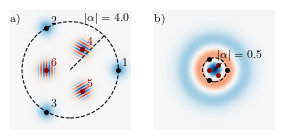

In [ ]:

fig, axes = plt.subplots(1,2,figsize = (colwidth, 0.5 * colwidth))
hbar = 2
N = 2
eps1 = 4
eps2 = 0.5

state1 = prepare_fock_coherent(N,1,eps1)
state1.normalise() #To get the log_norm

state2 = prepare_fock_coherent(N,1,eps2)
state2.normalise() #To get the log_norm

infid1 = order_infidelity_fock_coherent(N,eps1)
infid2 = order_infidelity_fock_coherent(N,eps2)
print('fidelity order of the approximation in b)', 1-infid2)

plot_coherent_state_radius(axes[0], state1, 'a)')
plot_coherent_state_radius(axes[1], state2, 'b)', xmax = 5,draw_extra=False)

plt.savefig(f'figures/figure_2.pdf',**fig_kwargs)
plt.show()

#title = ax.text(0.25,1.01,r' $\mathcal{F}= $'+'{:.5f} with Fock {}'.format(fid,N),transform=ax.transAxes, fontsize =12 )


In [205]:
def plot_centers_of_Gaussians(ax, state, label, xmax = 6, res = 300, factor = 5, circle=False, text=False):


    x = np.linspace(-xmax,xmax,res)
    
    means = state.means
    W = state.get_wigner_log(x,x).real

    real_means = means[0:state.num_k] * factor
    
    imag_means = means[state.num_k:]*factor
    
    im = plot_wig(W, x, x, colorbar = False, ax=ax, contourf=False)
    
    
    
    ax.scatter(real_means[:,0].real, real_means[:,1].real, marker='.',color='k', s= 8)
    
    if text:
        
        ax.text(0.125,0.9, rf'$n_c = {state.num_k}, \: n_w= {state.num_weights}$', transform=ax.transAxes )
    ax.text(0,0.9,label,transform=ax.transAxes)
    ax.set_axis_off()
    
    ax.set_aspect(1)
    if circle:
        radius = np.sqrt(real_means[:,0]**2+real_means[:,1]**2).real
        Drawing_uncolored_circle = plt.Circle( (0,0 ), radius[0] ,fill = False, color = 'black' , linestyle='dashed',linewidth=0.75)
        im_circ = ax.add_artist(Drawing_uncolored_circle )


Sgate[0.120,0.000] on mode 0
Sgate[-0.612,0.000] on mode 1
Sgate[-0.209,0.000] on mode 2
Sgate[0.953,0.000] on mode 3
BSgate[0.106,0.000] on modes 0 and 1
BSgate[0.267,0.000] on modes 2 and 3
BSgate[1.019,0.000] on modes 1 and 2
BSgate[1.232,0.000] on modes 0 and 1
BSgate[0.287,0.000] on modes 2 and 3
BSgate[0.888,0.000] on modes 1 and 2
Measuring 2 photons in mode 0.
Data shape before measurement, [(1, 8), (1, 8, 8)].
Probability of measurement = 2.887e-02
Data shape after measurement, [(6, 6), (1, 6, 6)]
Measuring 3 photons in mode 0.
Data shape before measurement, [(6, 6), (1, 6, 6)].
Probability of measurement = 1.022e-03
Data shape after measurement, [(78, 4), (1, 4, 4)]
Measuring 4 photons in mode 0.
Data shape before measurement, [(78, 4), (1, 4, 4)].
Probability of measurement = 3.142e-05
Data shape after measurement, [(1830, 2), (1, 2, 2)]


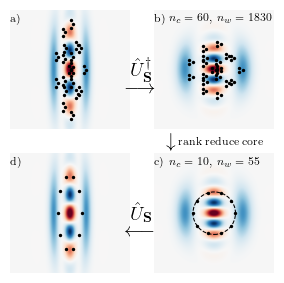

In [213]:
#Generate the state

from lcg_plus.operations.circuit_parameters import gen_interferometer_params
from lcg_plus.operations.gbs import build_interferometer
from thewalrus.decompositions import williamson
from lcg_plus.states.coherent import eps_superpos_coherent
from lcg_plus.states.reduce import reduce_log_pure


fig, axes = plt.subplots(2,2,figsize = (colwidth, colwidth), sharex=True, sharey=True)

num = 4 #Number of modes
n = 3
ns = np.repeat(n, num-1) #Photon pattern
ns = np.array([2,3,4])
nmax = sum(ns)
infid = 1e-6
#np.random.seed(19) #Seed for random circuit parameters
np.random.seed(100) #Seed for random circuit parameters

params = gen_interferometer_params(num, -12)

state = build_interferometer(params, num, out = True)

for i, n in enumerate(ns):
    state.post_select_fock_coherent(0, n, inf=1e-6, out=True )


#First plot the centers of the original state
plot_centers_of_Gaussians(axes[0,0], state, 'a)', factor=4)

#Remove the Gaussian operation
D, S = williamson(state.covs[0])
state.apply_symplectic(np.linalg.inv(S))

#Plot the centers of the original state with symplectic removed
plot_centers_of_Gaussians(axes[0,1], state, 'b)', factor=4, text=True)

data = state.means, state.covs, state.log_weights, state.num_k
        
eps = eps_superpos_coherent(nmax, infid)
new_data = reduce_log_pure(nmax, eps, data)

state.update_data(new_data)
state.get_norm()
state.normalise()

#Plot the centers of the reduced state with symplectic removed
plot_centers_of_Gaussians(axes[1,1], state, 'c)', factor=1, circle=True, text=True)

#Re-apply the squeezing
state.apply_symplectic(S)

#Plot the centers of the reduced state with symplectic added back
plot_centers_of_Gaussians(axes[1,0], state, 'd)', factor=1)

#Arrows
axes[1,1].text(-0.25,1.5,r'$\longrightarrow$',fontsize=14,transform=axes[1,1].transAxes)
axes[1,1].text(-0.2,1.65, r'$\hat{U}_{\mathbf{S}}^\dagger$',fontsize=14,transform=axes[1,1].transAxes)

axes[1,1].text(0.1,1.05,r'$\downarrow$',fontsize=14,transform=axes[1,1].transAxes)
axes[1,1].text(0.2,1.075, 'rank reduce core',fontsize=8,transform=axes[1,1].transAxes)

axes[1,1].text(-0.25,0.3,r'$\longleftarrow$',fontsize=14,transform=axes[1,1].transAxes)
axes[1,1].text(-0.2,0.45, r'$\hat{U}_{\mathbf{S}}$',fontsize=14,transform=axes[1,1].transAxes)

#Fidelity


plt.savefig(f'figures/figure_4.pdf',**fig_kwargs)
plt.show()

